# Macro Barometer — Research Notebook

Three validation stages before trusting the model:
1. **Visual validation** — do layer Z-scores align with known macro regimes?
2. **Cross-correlation** — do ETF signals statistically lead FRED macro data?
3. **Regime filter** — composite score aggregating all 6 layers into a single macro climate signal

In [19]:
import sys
sys.path.insert(0, '.')  # ensure local modules resolve

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

from main import load

plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# -- Load data (uses cache if already pulled today) --
data, analysis = load()

prices    = data['etf_prices']
fred      = data['fred_data']
layer_60  = analysis['layer_scores_60d']
layer_20  = analysis['layer_scores_20d']
zscore_60 = analysis['zscore_60d']
zscore_20 = analysis['zscore_20d']
ratios    = analysis['ratios']
ratio_z60 = analysis['ratio_zscore_60d']
pct_rank  = analysis['pct_rank_252d']

print('ETF prices:', prices.shape, '|', prices.index[0].date(), '->', prices.index[-1].date())
print('FRED data: ', fred.shape)
print('Layers:    ', list(layer_60.columns))

[data_pull] Cache is current. Loading from disk...
[analysis] Running full analysis pipeline...
[analysis] Computing 252-day percentile ranks (slow, one-time)...
[analysis] Done.
ETF prices: (4084, 38) | 2010-01-04 -> 2026-03-30
FRED data:  (4291, 4)
Layers:     ['L1_rates_liquidity', 'L2_global_growth', 'L3_domestic_cycle', 'L4_risk_appetite', 'L5_inflation_commodities', 'L6_stress_dislocation']


---
## 1. Visual Validation

Plot each layer Z-score against SPY price. Mark four known macro events:
- **2018-12**: Fed rate hike + December equity crash
- **2020-02**: COVID crash
- **2020-04**: COVID recovery / Fed QE response
- **2022-03**: Fed rate hike cycle begins

**What to look for:** Layers should break below 0 *before or concurrent with* equity drawdowns — not after.

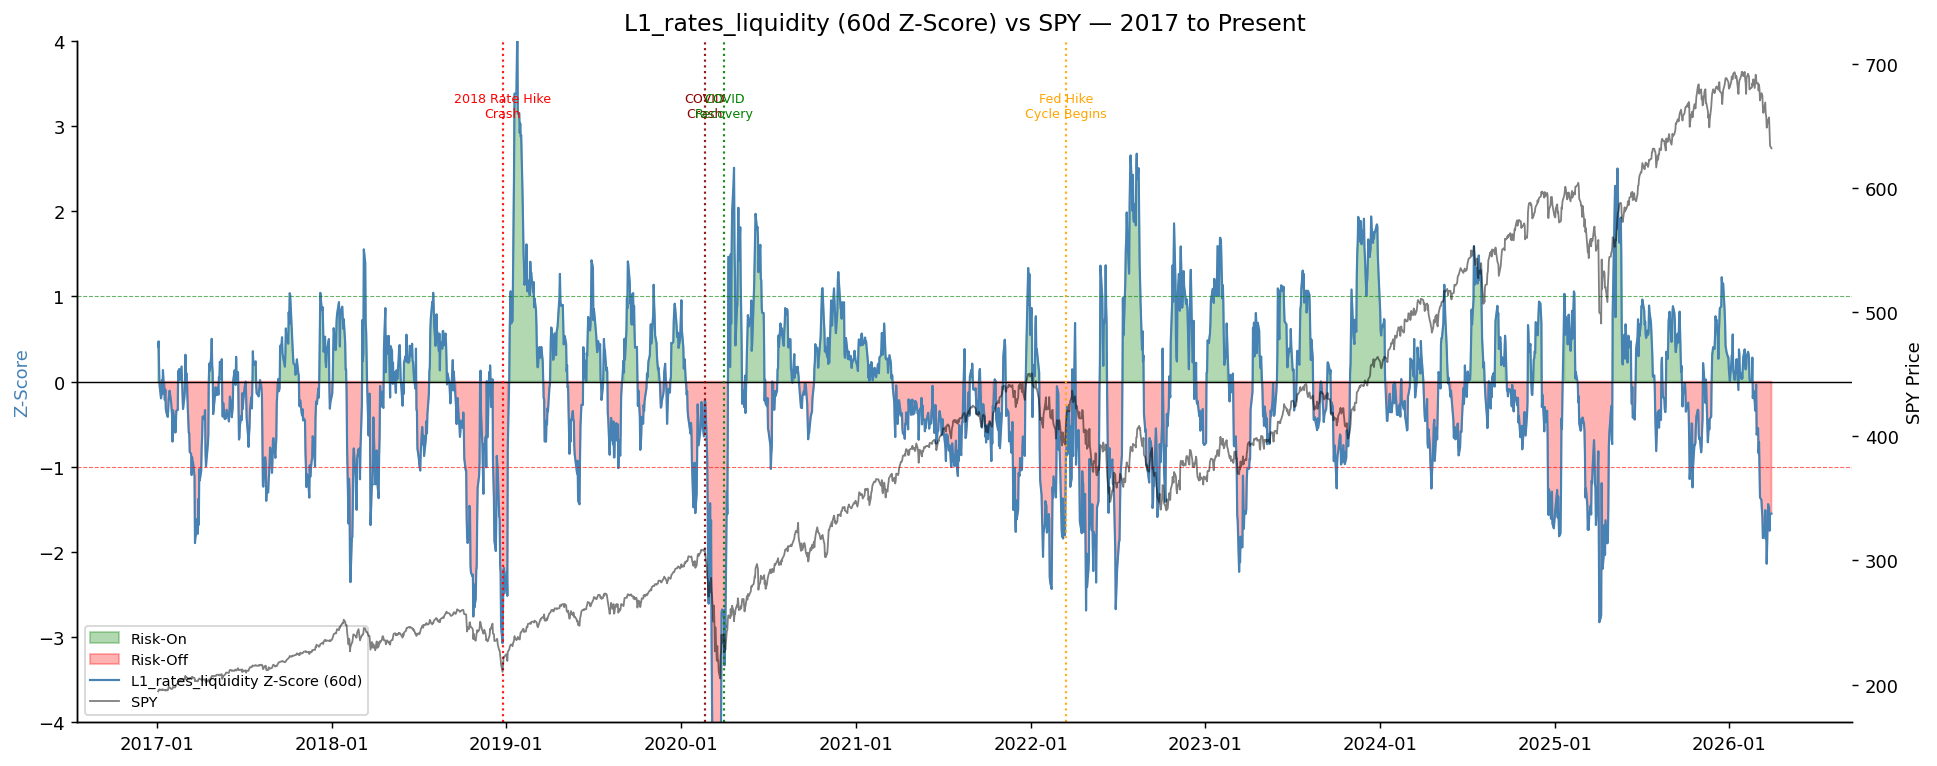

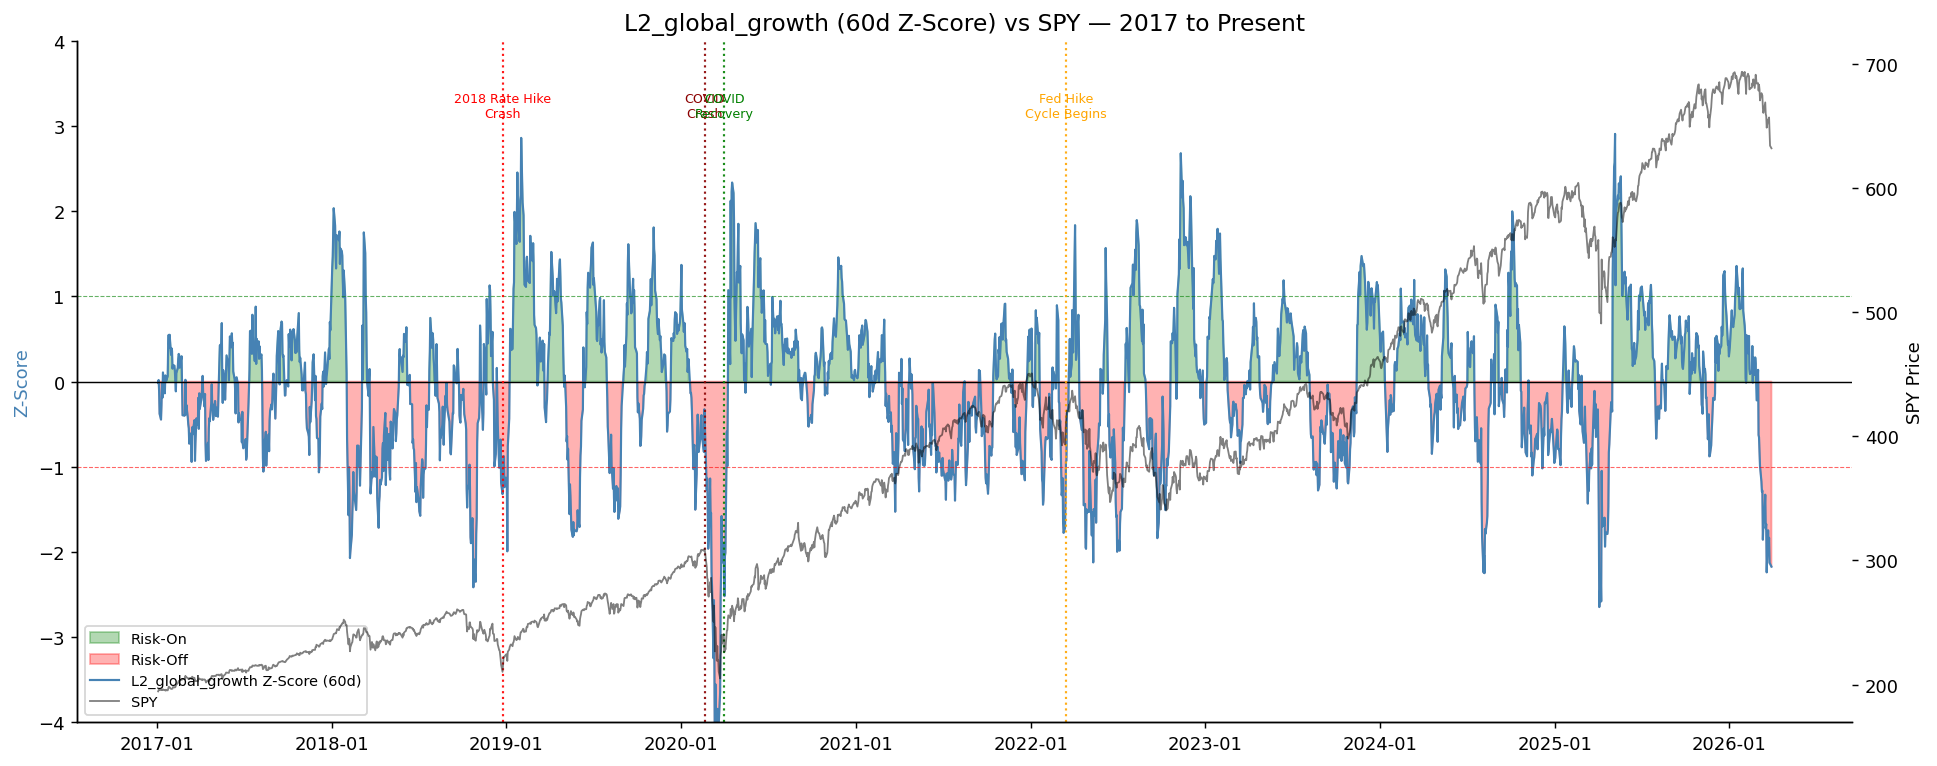

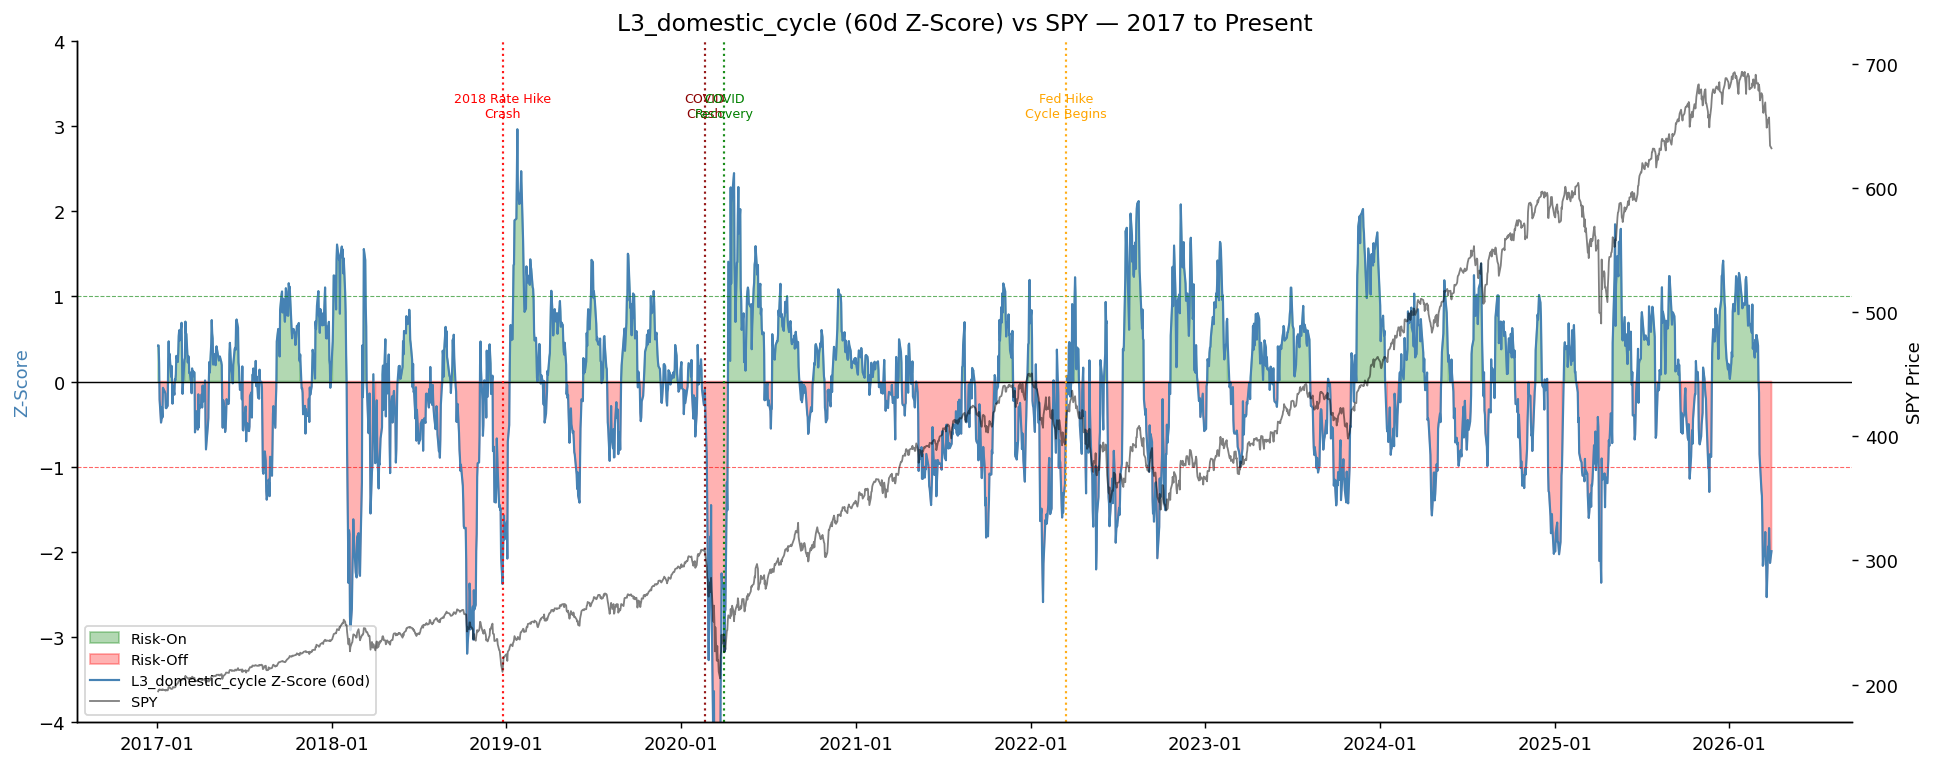

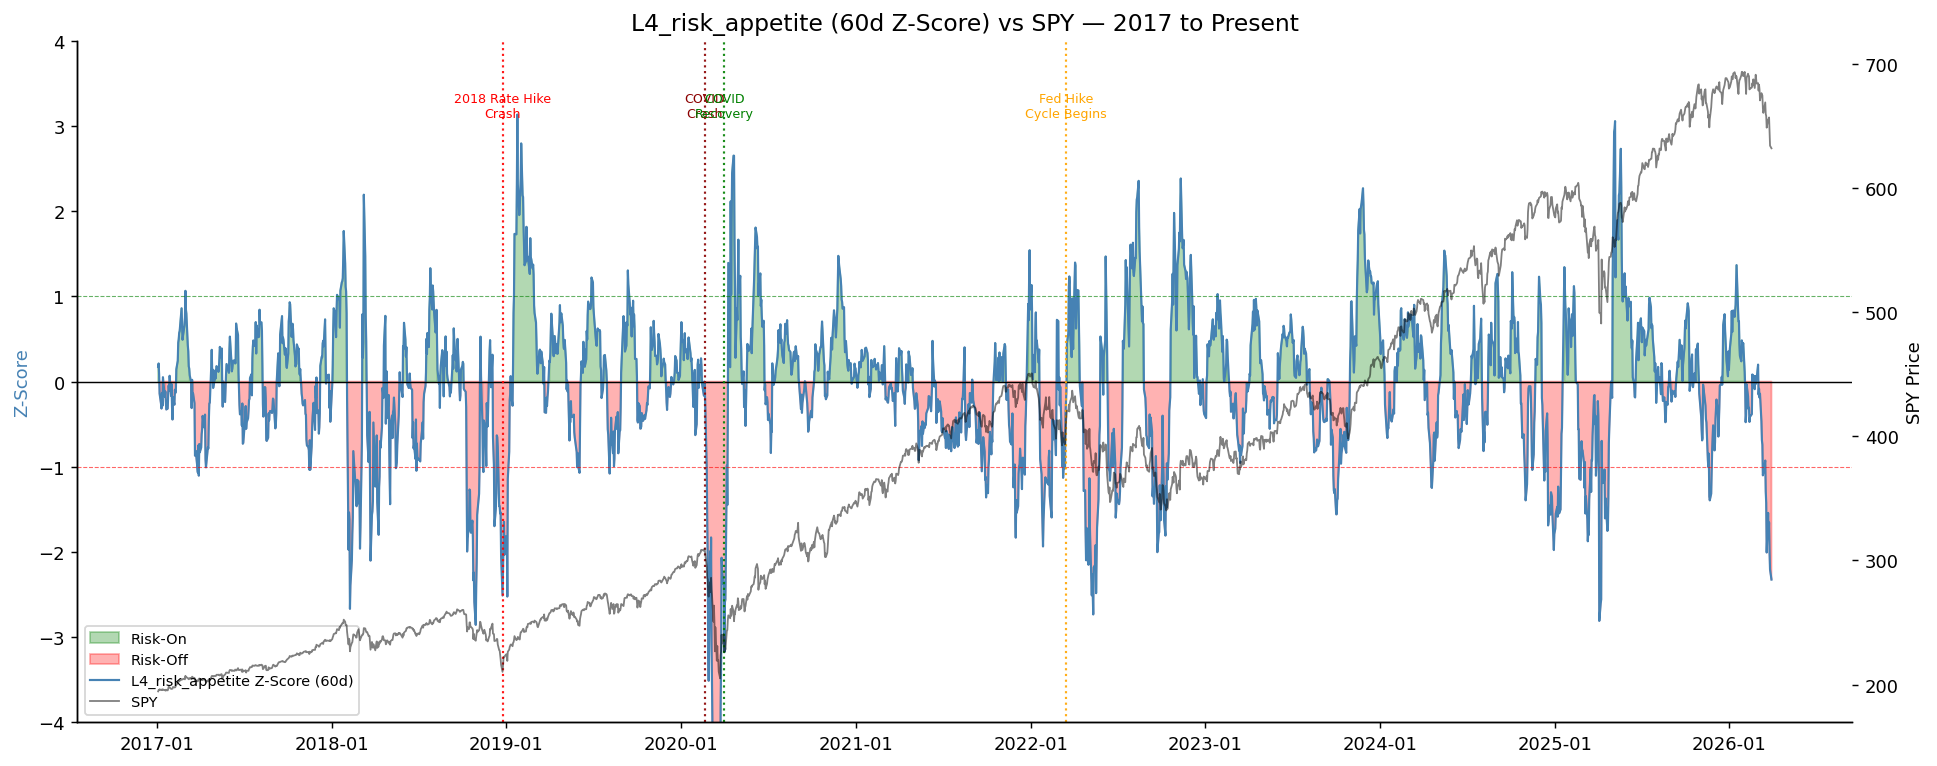

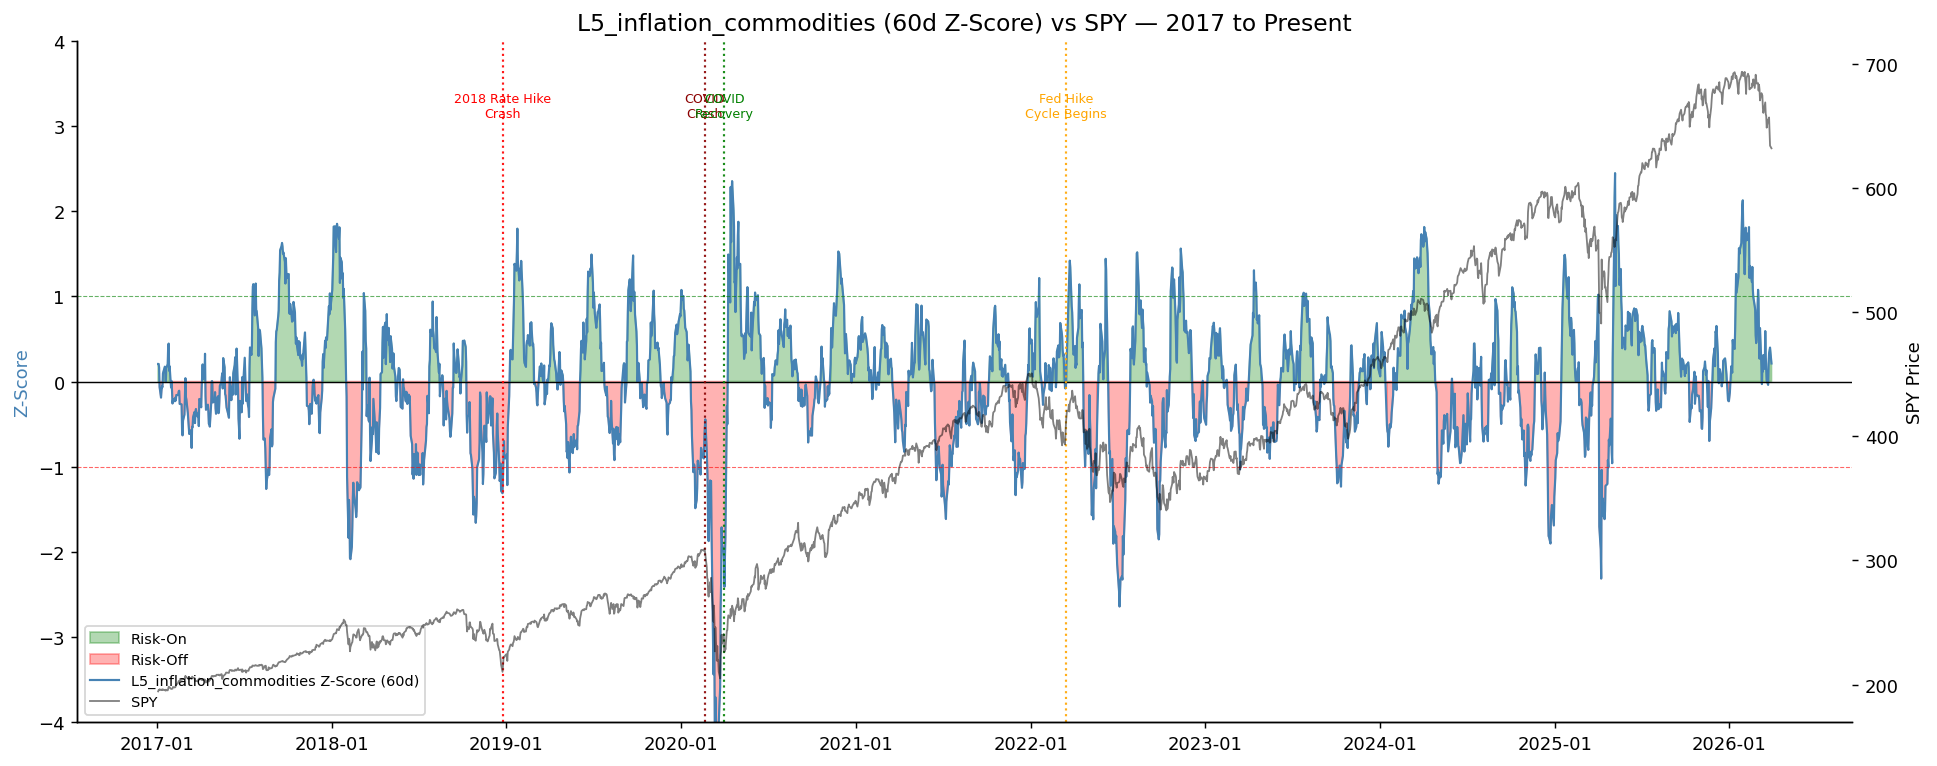

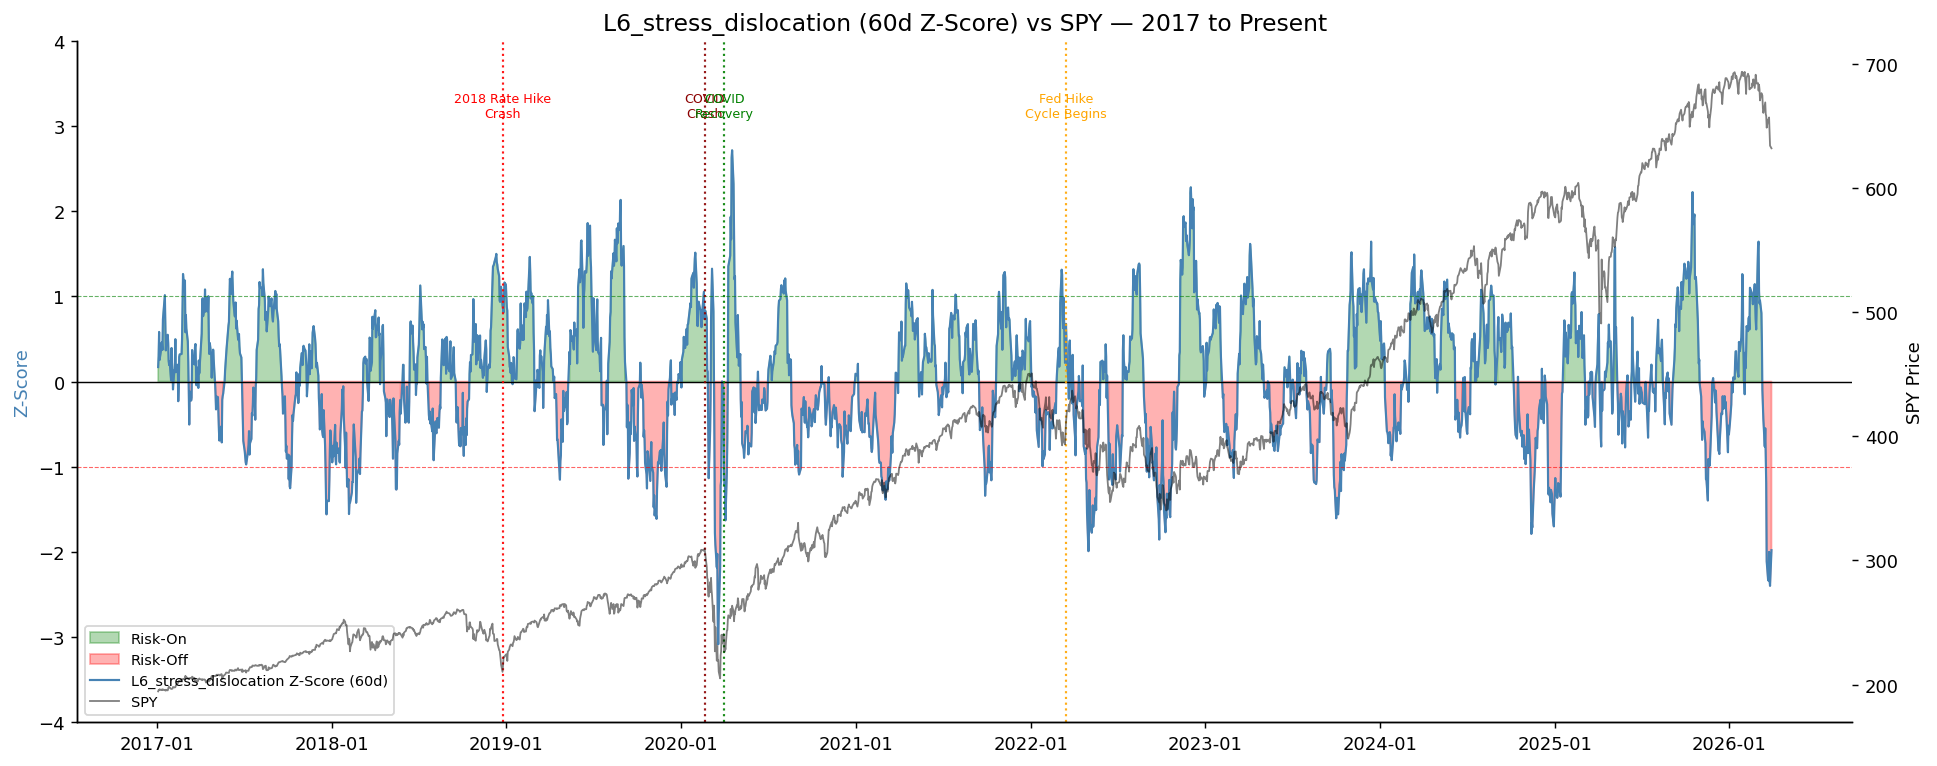

In [20]:
MACRO_EVENTS = {
    '2018-12-24': ('2018 Rate Hike\nCrash',    'red'),
    '2020-02-20': ('COVID\nCrash',              'darkred'),
    '2020-04-01': ('COVID\nRecovery',           'green'),
    '2022-03-16': ('Fed Hike\nCycle Begins',    'orange'),
}

def plot_layer_vs_spy(layer_name: str, window_start: str = '2017'):
    layer_series = layer_60[layer_name].loc[window_start:]
    spy_series   = prices['SPY'].loc[window_start:]

    fig, ax1 = plt.subplots(figsize=(15, 6))
    ax2 = ax1.twinx()

    # Layer Z-score (left axis)
    ax1.fill_between(layer_series.index, layer_series, 0,
                     where=layer_series >= 0, alpha=0.3, color='green', label='Risk-On')
    ax1.fill_between(layer_series.index, layer_series, 0,
                     where=layer_series < 0,  alpha=0.3, color='red',   label='Risk-Off')
    ax1.plot(layer_series.index, layer_series, color='steelblue', linewidth=1.2, label=f'{layer_name} Z-Score (60d)')
    ax1.axhline(0,  color='black', linewidth=0.8)
    ax1.axhline(1,  color='green', linewidth=0.6, linestyle='--', alpha=0.6)
    ax1.axhline(-1, color='red',   linewidth=0.6, linestyle='--', alpha=0.6)
    ax1.set_ylabel('Z-Score', color='steelblue')
    ax1.set_ylim(-4, 4)

    # SPY price (right axis)
    ax2.plot(spy_series.index, spy_series, color='black', linewidth=1, alpha=0.5, label='SPY')
    ax2.set_ylabel('SPY Price', color='black')

    # Event markers
    for date_str, (label, color) in MACRO_EVENTS.items():
        dt = pd.to_datetime(date_str)
        if dt >= pd.to_datetime(window_start):
            ax1.axvline(dt, color=color, linewidth=1.2, linestyle=':', alpha=0.9)
            ax1.text(dt, 3.4, label, fontsize=7, color=color, ha='center', va='top')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left', fontsize=8)

    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.title(f'{layer_name} (60d Z-Score) vs SPY — {window_start} to Present', fontsize=13)
    fig.tight_layout()
    plt.show()

# Run for all 6 layers
for layer in layer_60.columns:
    plot_layer_vs_spy(layer)

### 1b. All Layers Side-by-Side (Heatmap)
Quick regime snapshot across the full 15-year history. Each row = one layer, color = Z-score intensity.

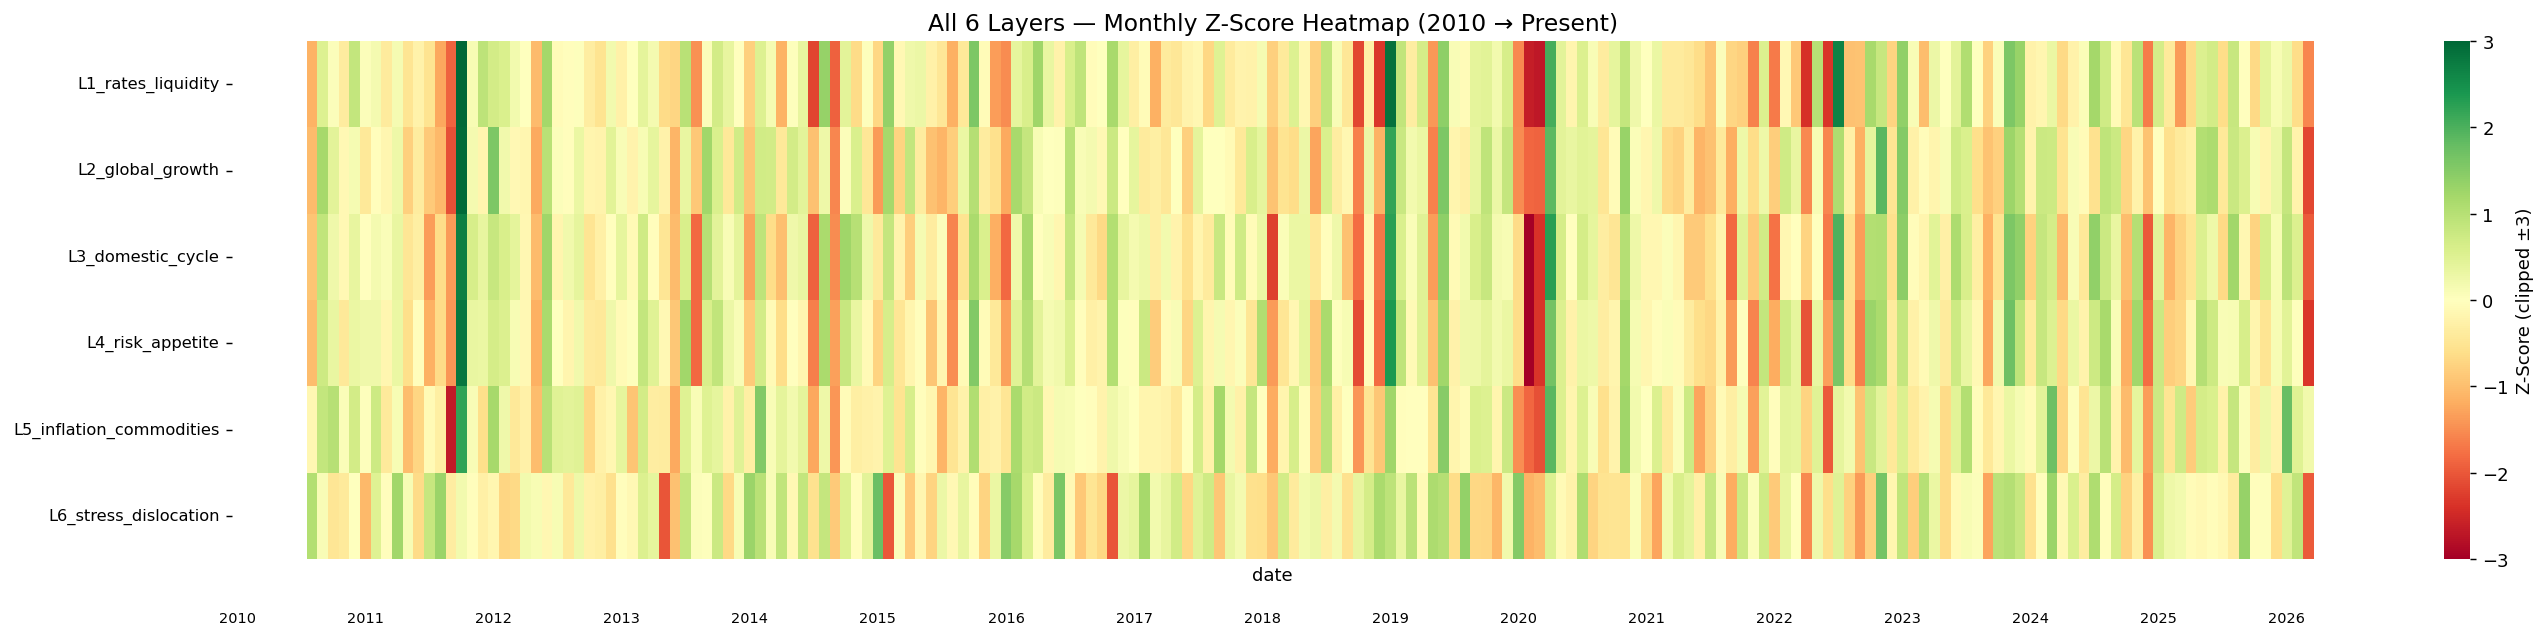

In [21]:
# Resample to monthly for readability
monthly_layers = layer_60.resample('ME').last().T  # shape: (6 layers, months)

# Clip to [-3, 3] so one extreme event doesn't wash out the colormap
monthly_clipped = monthly_layers.clip(-3, 3)

fig, ax = plt.subplots(figsize=(22, 5))
sns.heatmap(
    monthly_clipped,
    cmap='RdYlGn',
    center=0,
    vmin=-3, vmax=3,
    linewidths=0,
    ax=ax,
    cbar_kws={'label': 'Z-Score (clipped ±3)'},
    xticklabels=False,   # too many months; use the next line for year labels
)

# Add year labels manually
col_dates = pd.to_datetime(monthly_layers.columns)
year_positions = {}
for i, d in enumerate(col_dates):
    if d.month == 1:
        year_positions[str(d.year)] = i
for year_str, pos in year_positions.items():
    ax.text(pos + 0.5, 6.6, year_str, fontsize=8, ha='center', va='top')

ax.set_yticklabels(monthly_clipped.index, rotation=0, fontsize=9)
plt.title('All 6 Layers — Monthly Z-Score Heatmap (2010 → Present)', fontsize=13)
fig.tight_layout()
plt.show()

---
## 2. Cross-Correlation: Prove the Lead/Lag Relationships

Shift FRED data **backwards** by N months. If correlation peaks at lag=6,
the ETF signal today predicts the macro data 6 months from now.

| ETF Signal | FRED Series | Expected Peak Lag |
|---|---|---|
| XHB 60d Z-Score | Housing Starts (`housing_starts`) | 3–6 months |
| COPX/FCX avg Z-Score | ISM Manufacturing (`ism_manufacturing`) | 3–9 months |
| HYG/LQD ratio Z-Score | 2yr Yield (`yield_2yr`) | 1–3 months |
| L3 Domestic Cycle | Housing Starts | 6–12 months |

In [22]:
def lagged_correlation(
    signal: pd.Series,
    target: pd.Series,
    max_lag_months: int = 12,
    resample_freq: str = 'ME',
) -> pd.Series:
    """
    Correlates `signal` (today) with `target` shifted -lag months (future).
    Positive lag = signal leads target.
    Returns a Series indexed by lag (months).
    """
    s = signal.resample(resample_freq).last().dropna()
    t = target.resample(resample_freq).last().dropna()

    # Align on common index
    s, t = s.align(t, join='inner')

    results = {}
    for lag in range(0, max_lag_months + 1):
        t_shifted = t.shift(-lag)          # future FRED data
        combined  = pd.concat([s, t_shifted], axis=1).dropna()
        if len(combined) < 24:             # need at least 2 years of overlap
            results[lag] = np.nan
        else:
            r, _ = stats.pearsonr(combined.iloc[:, 0], combined.iloc[:, 1])
            results[lag] = r

    return pd.Series(results, name=f"{signal.name} → {target.name}")


def plot_lag_correlations(pairs: list[tuple], title: str):
    fig, axes = plt.subplots(1, len(pairs), figsize=(6 * len(pairs), 5), sharey=True)
    if len(pairs) == 1:
        axes = [axes]

    for ax, (signal, target, label) in zip(axes, pairs):
        corrs = lagged_correlation(signal, target)
        colors = ['green' if c > 0 else 'red' for c in corrs]
        ax.bar(corrs.index, corrs.values, color=colors, alpha=0.8)
        ax.axhline(0, color='black', linewidth=0.8)
        ax.axhline(0.3,  color='green', linestyle='--', linewidth=0.7, alpha=0.6)
        ax.axhline(-0.3, color='red',   linestyle='--', linewidth=0.7, alpha=0.6)
        peak_lag = corrs.abs().idxmax()
        ax.axvline(peak_lag, color='navy', linestyle=':', linewidth=1.5)
        ax.set_title(f'{label}\nPeak lag: {peak_lag}M (r={corrs[peak_lag]:.2f})', fontsize=10)
        ax.set_xlabel('Led (months)')
        ax.set_ylabel('Pearson r')
        ax.set_ylim(-1, 1)
        ax.set_xticks(range(0, 13))

    fig.suptitle(title, fontsize=13, fontweight='bold')
    fig.tight_layout()
    plt.show()

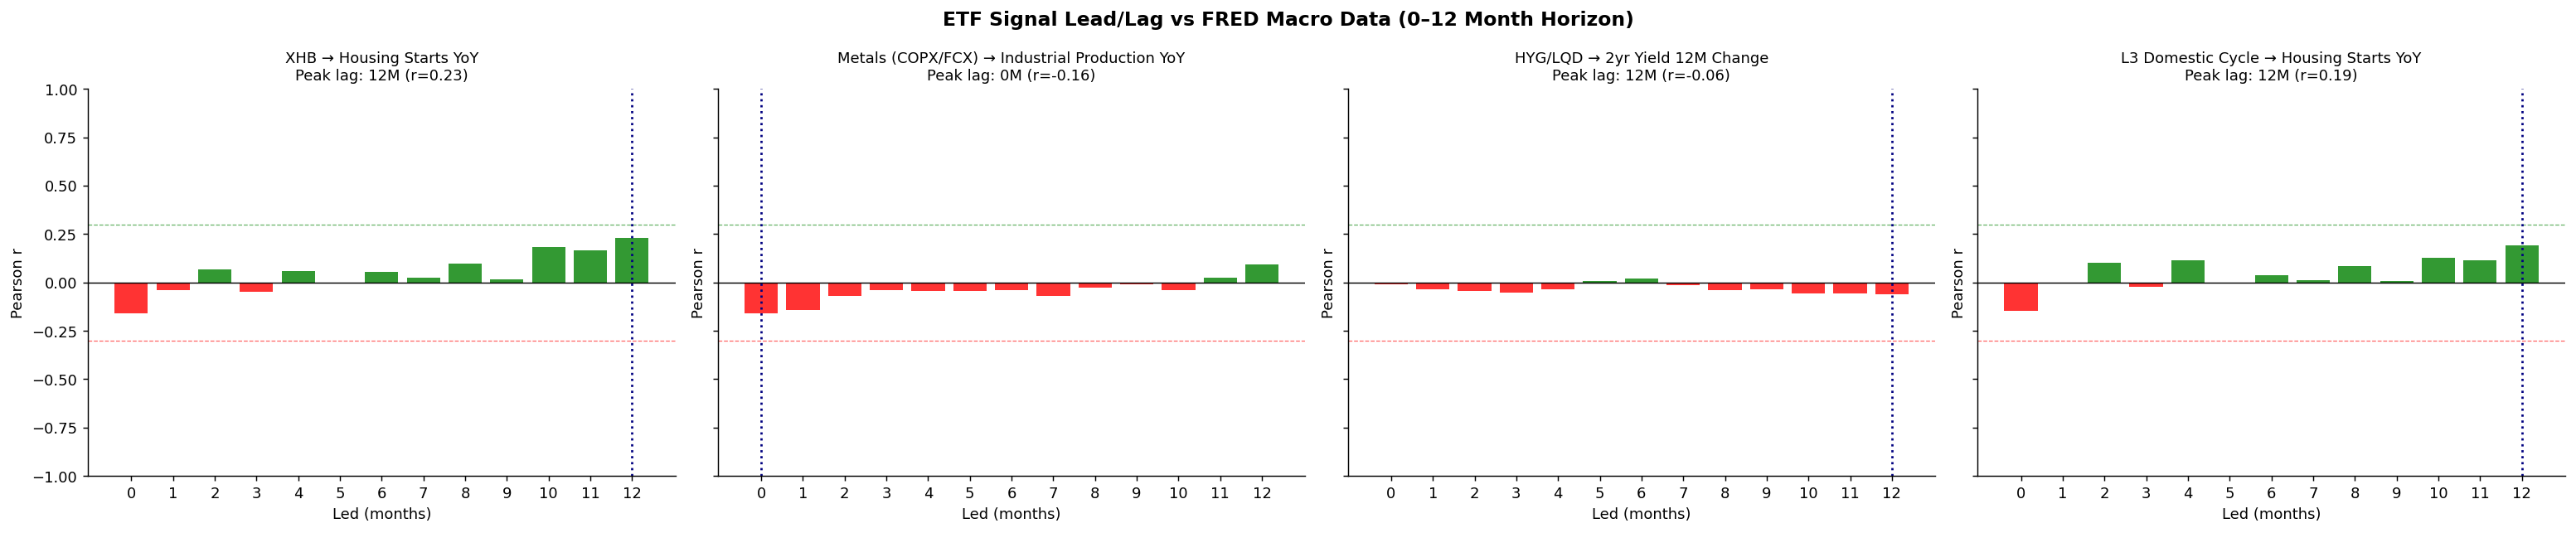

In [28]:
# --- Pair 1: Homebuilders vs Housing Starts YoY ---                                                                                
xhb_z    = analysis['zscore_regime']['XHB'].rename('XHB_zscore_regime')                                                             
houst    = fred['housing_starts'].resample('ME').last().pct_change(12).rename('HOUST_YoY')                                          
                                                                                                                                      
  # --- Pair 2: Metals vs Industrial Production YoY ---                                                                               
metals_z = analysis['zscore_regime'][['COPX', 'FCX']].mean(axis=1).rename('Metals_zscore_regime')                                   
ism      = fred['industrial_production'].resample('ME').last().pct_change(12).rename('INDPRO_YoY')                                  
                                                                                                                                      
  # --- Pair 3: HYG/LQD ratio Z-score vs 2yr Yield 12M change ---                                                                     
hyg_lqd_z = ratio_z60['HYG_LQD'].rename('HYG_LQD_ratio_zscore')                                                                     
yield_2yr  = fred['yield_2yr'].resample('ME').last().diff(12).rename('DGS2_12M_change')                                             
                                                                                                                                      
  # --- Pair 4: L3 Domestic Cycle vs Housing Starts YoY ---                                                                           
l3_z = layer_60['L3_domestic_cycle'].rename('L3_domestic_cycle')                                                                    
                                                                                                                                      
plot_lag_correlations(                                                                                                              
    pairs=[                                                                                                                         
          (xhb_z,     houst,     'XHB → Housing Starts YoY'),                                                                         
          (metals_z,  ism,       'Metals (COPX/FCX) → Industrial Production YoY'),                                                    
          (hyg_lqd_z, yield_2yr, 'HYG/LQD → 2yr Yield 12M Change'),                                                                   
          (l3_z,      houst,     'L3 Domestic Cycle → Housing Starts YoY'),                                                           
      ],                                                                                                                              
      title='ETF Signal Lead/Lag vs FRED Macro Data (0–12 Month Horizon)',                                                            
  )                                                                                                                                   
                                                                                      

In [30]:
print(prices['SPY'].loc['2020-03-23'])   # COVID bottom — should be ~$218                                                           
print(prices['SPY'].loc['2022-01-03'])   # 2022 peak — should be ~$477                                                              
print(fred['yield_2yr'].loc['2022-06-30':'2022-07-05'])  # should be ~3.0%  

204.9449005126953
450.6444091796875
date
2022-06-30    2.92
2022-07-01    2.84
2022-07-04     NaN
2022-07-05    2.82
Name: yield_2yr, dtype: float64


### 2b. Full Cross-Correlation Matrix
At a fixed lag (e.g. 6 months), what is each layer's correlation to each FRED series?

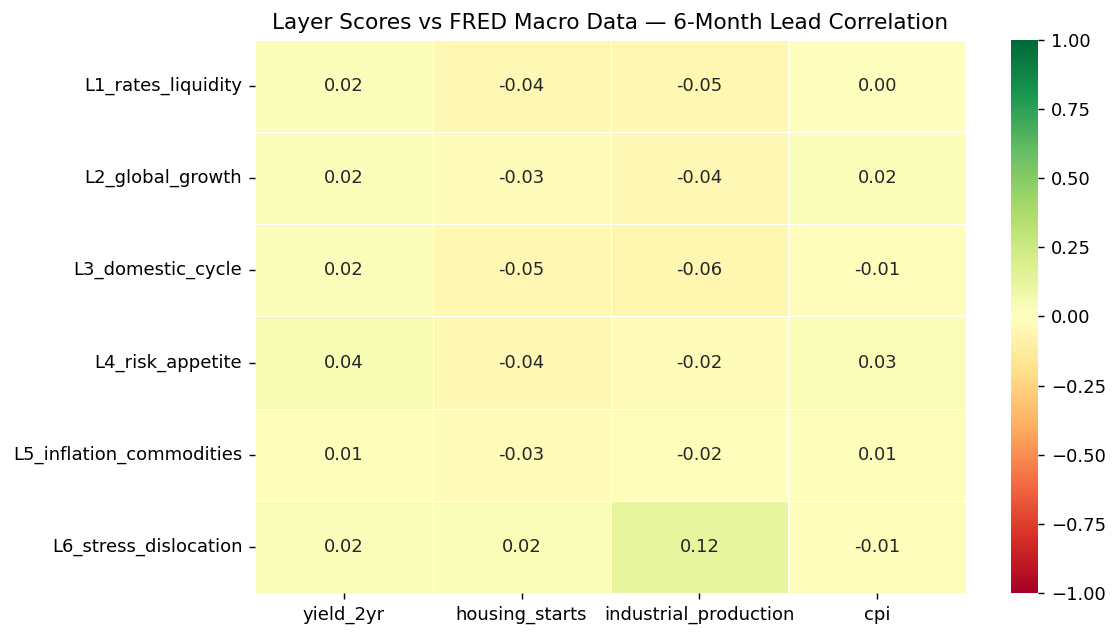

In [31]:
LAG_MONTHS = 6  # adjust after you see the bar charts above

monthly_layer = layer_60.resample('ME').last()
monthly_fred  = fred.resample('ME').last()

# Shift FRED forward by LAG_MONTHS (so layer today vs FRED in the future)
fred_future = monthly_fred.shift(-LAG_MONTHS)
combined    = pd.concat([monthly_layer, fred_future], axis=1).dropna()

corr_matrix = combined.corr().loc[layer_60.columns, fred.columns]

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax
)
ax.set_title(f'Layer Scores vs FRED Macro Data — {LAG_MONTHS}-Month Lead Correlation', fontsize=12)
fig.tight_layout()
plt.show()

---
## 3. Composite Regime Filter

Aggregate all 6 layers into a single **Macro Climate Score**.

### Sign convention
| Layer | Direction | Rationale |
|---|---|---|
| L1 Rates/Liquidity | +1 | HYG/JNK up = credit healthy, spreads tight |
| L2 Global Growth | +1 | Directly risk-on |
| L3 Domestic Cycle | +1 | Directly risk-on |
| L4 Risk Appetite | +1 | Directly risk-on |
| L5 Inflation/Commodities | +1 | Expansion-phase commodities rally |
| L6 Stress/Dislocation | **−1** | Inverted: high Z when defensives + bonds rally = stress |

> **Note on L6:** L6 contains XLU, TLT (defensive) alongside KRE, IWM (risk-on). In stress,
> defensive inflows offset risk-off outflows, so the raw z-score may *understate* stress.
> After seeing the data, you may want to split L6 into two sub-signals.

In [32]:
LAYER_SIGNS = {
    'L1_rates_liquidity':       +1,
    'L2_global_growth':         +1,
    'L3_domestic_cycle':        +1,
    'L4_risk_appetite':         +1,
    'L5_inflation_commodities': +1,
    'L6_stress_dislocation':    -1,   # inverted
}

# Sign-adjusted layer scores
signed = layer_60.copy()
for col, sign in LAYER_SIGNS.items():
    signed[col] = signed[col] * sign

# --- Method A: Continuous composite (mean of signed z-scores) ---
composite_continuous = signed.mean(axis=1).rename('macro_climate_continuous')

# --- Method B: Discrete regime signal (-1 / 0 / +1 per layer, sum across layers) ---
# Threshold: |z| > 0.5 counts as a directional signal
THRESHOLD = 0.5
discrete_signals = signed.apply(lambda col: np.where(col > THRESHOLD, 1,
                                               np.where(col < -THRESHOLD, -1, 0)))
composite_discrete = pd.Series(
    discrete_signals.sum(axis=1),
    index=layer_60.index,
    name='macro_climate_discrete'
)  # range: -6 to +6

print('Continuous composite stats (last 252 days):')
print(composite_continuous.tail(252).describe().round(3))
print('\nDiscrete composite value counts (last 252 days):')
print(composite_discrete.tail(252).value_counts().sort_index())

Continuous composite stats (last 252 days):
count    252.000
mean       0.077
std        0.644
min       -2.025
25%       -0.301
50%        0.132
75%        0.489
max        1.830
Name: macro_climate_continuous, dtype: float64

Discrete composite value counts (last 252 days):
macro_climate_discrete
-6     1
-5    13
-4    11
-3    21
-2    22
-1    13
 0    31
 1    41
 2    18
 3    30
 4    36
 5    12
 6     3
Name: count, dtype: int64


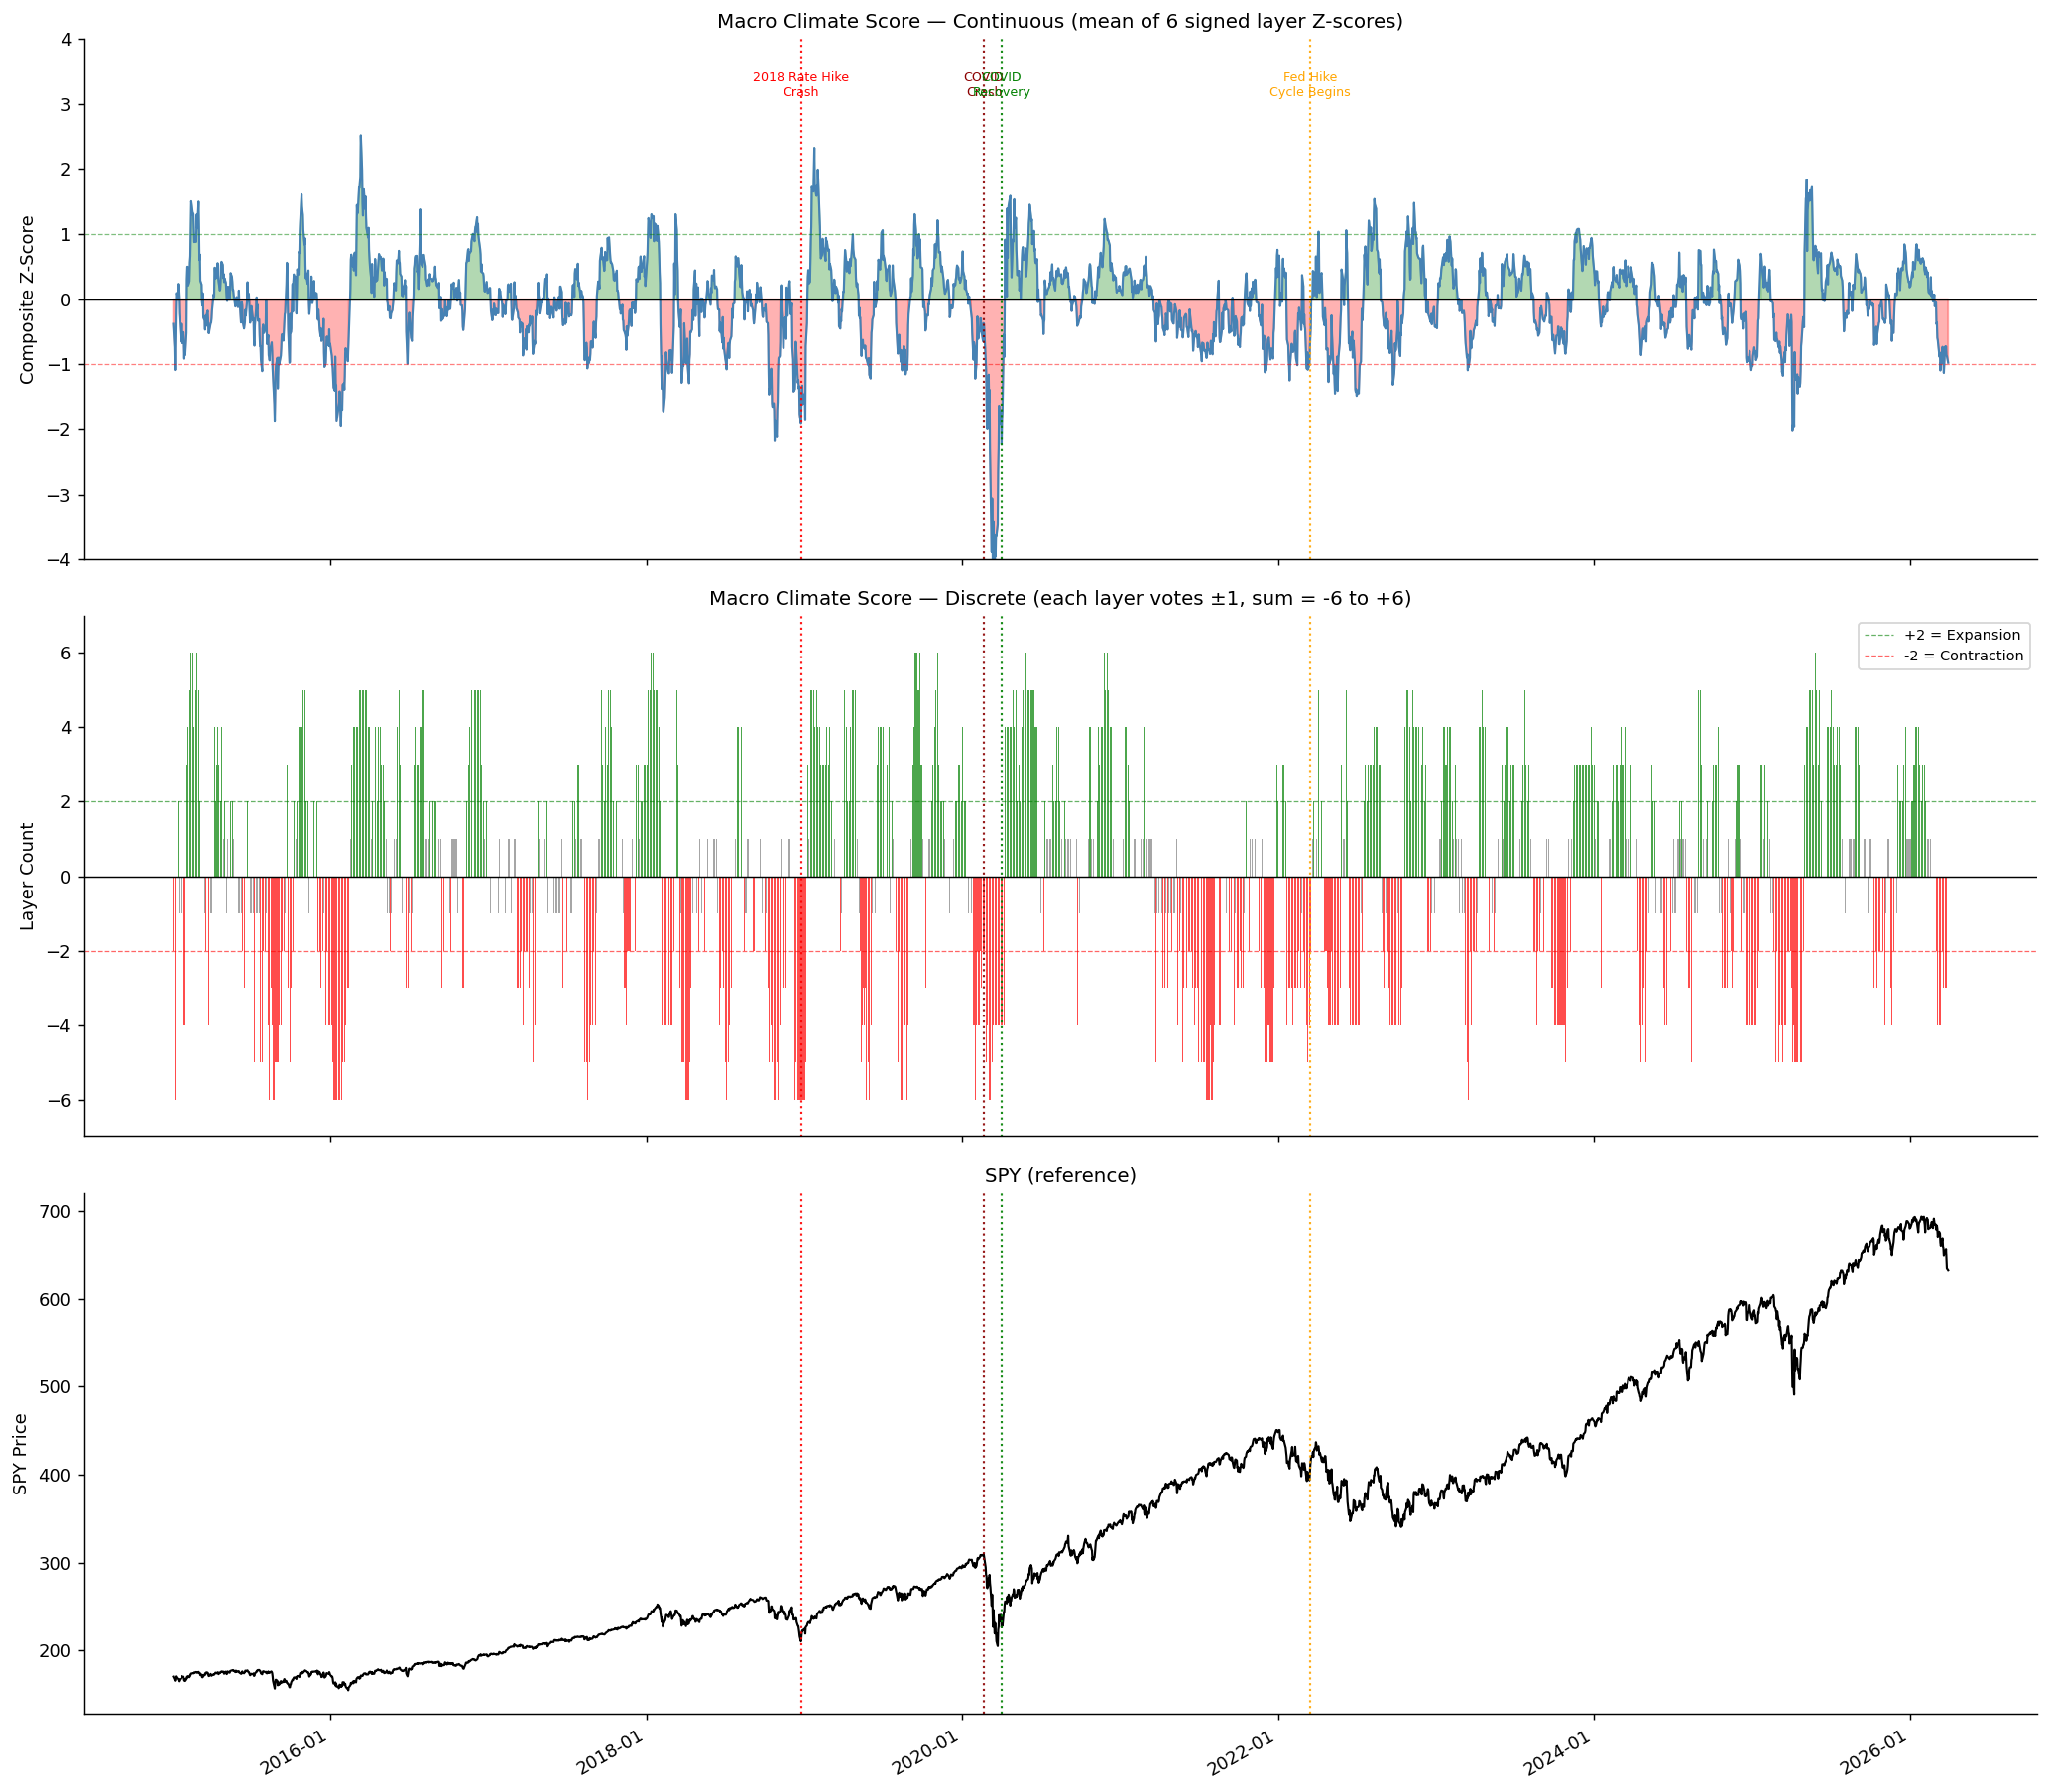

In [33]:
# --- Plot: Composite Regime vs SPY ---
fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)

start = '2015'
spy   = prices['SPY'].loc[start:]
cont  = composite_continuous.loc[start:]
disc  = composite_discrete.loc[start:]

# Panel 1: Continuous composite
ax = axes[0]
ax.fill_between(cont.index, cont, 0, where=cont >= 0, alpha=0.3, color='green')
ax.fill_between(cont.index, cont, 0, where=cont < 0,  alpha=0.3, color='red')
ax.plot(cont.index, cont, color='steelblue', linewidth=1.2)
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(1,  color='green', linestyle='--', linewidth=0.7, alpha=0.5)
ax.axhline(-1, color='red',   linestyle='--', linewidth=0.7, alpha=0.5)
ax.set_ylabel('Composite Z-Score')
ax.set_title('Macro Climate Score — Continuous (mean of 6 signed layer Z-scores)', fontsize=11)
ax.set_ylim(-4, 4)

# Panel 2: Discrete regime
ax = axes[1]
colors_disc = disc.map(lambda v: 'green' if v > 1 else ('red' if v < -1 else 'gray'))
ax.bar(disc.index, disc.values, color=colors_disc, width=1, alpha=0.7)
ax.axhline(0,  color='black', linewidth=0.8)
ax.axhline(2,  color='green', linestyle='--', linewidth=0.7, alpha=0.6, label='+2 = Expansion')
ax.axhline(-2, color='red',   linestyle='--', linewidth=0.7, alpha=0.6, label='-2 = Contraction')
ax.set_ylabel('Layer Count')
ax.set_title('Macro Climate Score — Discrete (each layer votes ±1, sum = -6 to +6)', fontsize=11)
ax.set_ylim(-7, 7)
ax.legend(fontsize=8)

# Panel 3: SPY price
ax = axes[2]
ax.plot(spy.index, spy, color='black', linewidth=1.2)
ax.set_ylabel('SPY Price')
ax.set_title('SPY (reference)', fontsize=11)

# Event lines on all panels
for date_str, (label, color) in MACRO_EVENTS.items():
    dt = pd.to_datetime(date_str)
    if dt >= pd.to_datetime(start):
        for ax in axes:
            ax.axvline(dt, color=color, linewidth=1.2, linestyle=':', alpha=0.9)
        axes[0].text(dt, 3.5, label, fontsize=7, color=color, ha='center', va='top')

axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=30, ha='right')
fig.tight_layout()
plt.show()

### 3b. Regime-Conditional SPY Forward Returns

Does a positive composite regime predict higher SPY returns going forward?
Bucket each day by discrete regime score, compute forward 1M/3M/6M SPY returns.

SPY Forward Returns by Macro Regime:


,1M_mean,1M_median,1M_n,3M_mean,3M_median,3M_n,6M_mean,6M_median,6M_n
bucket,,,,,,,,,
Contraction (≤-2),0.0144,0.0214,1276,0.0408,0.0485,1276,0.0774,0.0802,1253
Neutral (-1 to 1),0.0093,0.0146,1560,0.0314,0.0410,1544,0.0673,0.0776,1518
Expansion (≥2),0.0118,0.0154,1227,0.0346,0.0429,1201,0.0718,0.0759,1187


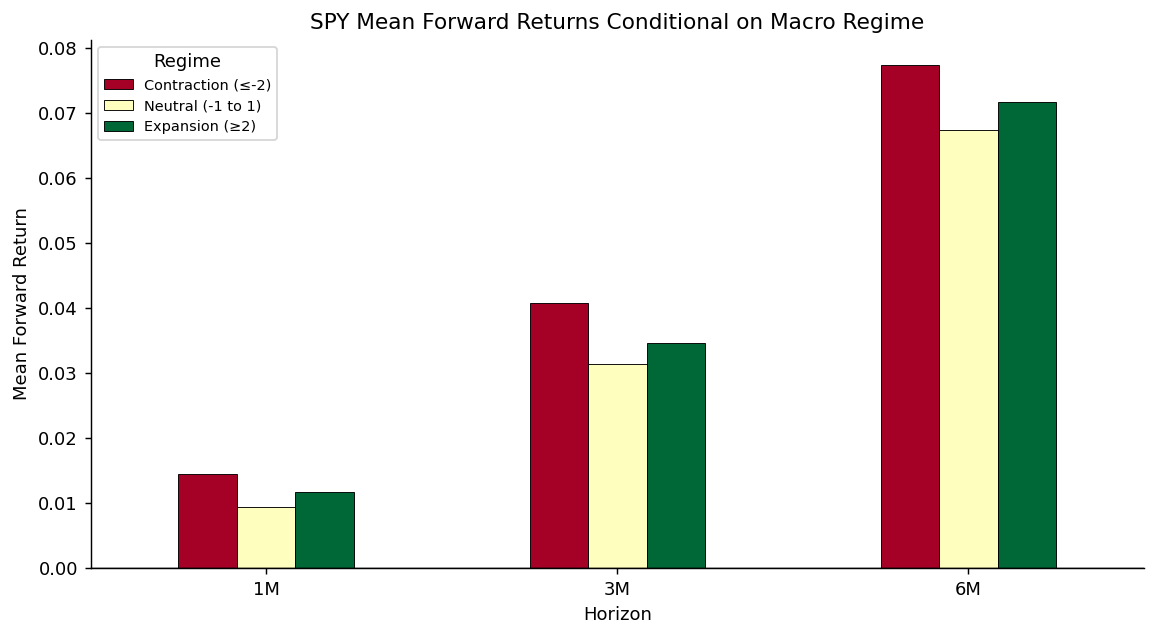

In [34]:
spy_returns = prices['SPY'].pct_change()

horizons = {'1M': 21, '3M': 63, '6M': 126}

results = []
for label, n_days in horizons.items():
    fwd_ret = prices['SPY'].pct_change(n_days).shift(-n_days)  # forward return
    combined = pd.DataFrame({
        'regime': composite_discrete,
        'fwd_ret': fwd_ret
    }).dropna()
    # Bucket into Expansion (≥2), Neutral (-1 to 1), Contraction (≤-2)
    combined['bucket'] = pd.cut(
        combined['regime'],
        bins=[-7, -2, 1, 7],
        labels=['Contraction (≤-2)', 'Neutral (-1 to 1)', 'Expansion (≥2)']
    )
    summary = combined.groupby('bucket', observed=True)['fwd_ret'].agg(['mean', 'median', 'count'])
    summary.columns = [f'{label}_mean', f'{label}_median', f'{label}_n']
    results.append(summary)

regime_returns = pd.concat(results, axis=1)
print('SPY Forward Returns by Macro Regime:')
display(regime_returns.round(4))

# Plot means
mean_cols = [c for c in regime_returns.columns if 'mean' in c]
plot_data = regime_returns[mean_cols].copy()
plot_data.columns = ['1M', '3M', '6M']

fig, ax = plt.subplots(figsize=(9, 5))
plot_data.T.plot(kind='bar', ax=ax, colormap='RdYlGn', edgecolor='black', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Mean Forward Return')
ax.set_xlabel('Horizon')
ax.set_title('SPY Mean Forward Returns Conditional on Macro Regime', fontsize=12)
ax.legend(title='Regime', fontsize=8)
plt.xticks(rotation=0)
fig.tight_layout()
plt.show()

---
## 4. Current Snapshot

Where does the model stand **today**? Print a clean dashboard table.

In [35]:
today = layer_60.index[-1]

snapshot = pd.DataFrame({
    'Layer Z-Score (20d)':  layer_20.iloc[-1],
    'Layer Z-Score (60d)':  layer_60.iloc[-1],
    'Regime Vote (60d)':    discrete_signals.iloc[-1].rename(index=lambda x: x),
}).round(3)

snapshot['Signal'] = snapshot['Regime Vote (60d)'].map({1: 'RISK-ON', -1: 'RISK-OFF', 0: 'NEUTRAL'})

print(f'\n=== Macro Barometer Snapshot — {today.date()} ===')
display(snapshot)

cont_today = composite_continuous.iloc[-1]
disc_today = composite_discrete.iloc[-1]
print(f'\nComposite Continuous Score : {cont_today:.3f}')
print(f'Composite Discrete Score   : {int(disc_today)} / 6')

if disc_today >= 3:
    print('Macro Climate: EXPANSION')
elif disc_today <= -3:
    print('Macro Climate: CONTRACTION')
else:
    print('Macro Climate: TRANSITIONAL / MIXED')

print('\nKey Ratios (current levels):')
ratio_today = ratios.iloc[-1]
for col in ratios.columns:
    a, b = col.split('_')
    print(f'  {a}/{b}: {ratio_today[col]:.4f}')


=== Macro Barometer Snapshot — 2026-03-30 ===


,Layer Z-Score (20d),Layer Z-Score (60d),Regime Vote (60d),Signal
L1_rates_liquidity,0.588,-1.550,-1,RISK-OFF
L2_global_growth,-0.429,-2.172,-1,RISK-OFF
L3_domestic_cycle,0.114,-1.991,-1,RISK-OFF
L4_risk_appetite,-0.099,-2.324,-1,RISK-OFF
L5_inflation_commodities,-0.192,0.213,0,NEUTRAL
L6_stress_dislocation,0.979,-1.978,1,RISK-ON



Composite Continuous Score : -0.974
Composite Discrete Score   : -3 / 6
Macro Climate: CONTRACTION

Key Ratios (current levels):
  XLY/XLP: 1.2904
  XLF/XLU: 1.0531
  IWM/SPY: 0.3791
  SOXX/SPY: 0.4902
  IVE/IVW: 1.9099
  EEM/SPY: 0.0866
  HYG/LQD: 0.7276
